# 04 Geographic Analysis - Regional Market Analysis

## Project Background
In e-commerce business, different geographic regions often exhibit substantial differences in performance. States and cities may vary significantly in terms of order volume, spending power, product preferences, logistics efficiency, and customer satisfaction.
Therefore, analyzing the business only from an overall perspective is not sufficient. A geographic perspective is needed to identify which regions are core markets, which have strong growth potential, and which still face challenges in logistics and service quality.

This project is based on order, customer, product, seller, delivery, and review data. It aims to conduct a systematic geographic analysis of e-commerce performance from a spatial perspective. By building state-level and city-level regional indicators, and combining sales performance, delivery efficiency, customer satisfaction, and product preference analysis, this project seeks to uncover meaningful regional patterns and provide data support for regional operations and market expansion strategies.

## Project Objectives
- Identify high-value regions and potential growth markets
- Analyze regional differences in spending power and product preferences
- Optimize logistics performance and region-specific operations
- Provide insights to support market expansion decisions

## Key Business Questions
1. Which states and cities contribute the most orders and revenue?
2. Is e-commerce revenue concentrated in a small number of core regions?
3. Are there significant regional differences in average order value, repeat purchase behavior, and customer value?
4. How do different regions perform in delivery time, delay rate, and freight cost?
5. Is regional customer satisfaction associated with logistics performance?
6. Do different regions show distinct product category preferences?
7. How can region-specific strategies be designed based on these regional characteristics?

## Analytical Framework
- Geographic sales distribution: identify state-level and city-level sales patterns
- Regional segmentation: classify regions based on sales, satisfaction, and logistics indicators
- Logistics optimization: analyze delivery time, delay rate, and freight cost
- Product preference analysis: identify regional category preferences and specialty products
- Regional strategy design: propose differentiated strategies for different regional types

## Data Sources
This project mainly uses the following tables and analytical views:
- `view_geographic_state_summary`: state-level geographic summary view
- `view_geographic_city_summary`: city-level geographic summary view
- `view_buyer_seller_distance`: buyer-seller regional relationship view
- `fact_order`: order fact table
- `fact_order_item`: order item fact table
- `dim_user`: user dimension table
- `dim_product`: product dimension table
- `sellers_raw`: seller raw table
- `fact_review`: review fact table

## Expected Outputs
This project is expected to generate the following key outputs:
- Regional sales ranking and sales concentration analysis
- State-level and city-level geographic visualizations
- Regional segmentation model and regional profiles
- Logistics problem regions and major trade route analysis
- Regional product preference and specialty product identification
- Regional operation and market expansion recommendations

## 1. Data Loading & Initial Exploration

In [2]:
# Import library code units
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore')

# Geographic visualization
import plotly.express as px
import plotly.graph_objects as go

# Display settings
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

# Visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)

### 1.1 State-level Data Loading

To analyse regional business performance, the first step is to load a state-level aggregated dataset from the MySQL data warehouse. This table summarises the key regional business indicators for each customer state, including order volume, customer count, GMV, revenue, average order value, delivery performance, freight cost, review score, bad review rate, and repeat-purchase proxy. Since the data is already aggregated at the state level, each row represents one state rather than one individual order or one customer. This dataset is suitable for high-level regional comparison, including sales ranking, regional clustering, satisfaction comparison, and logistics performance evaluation.

In [3]:
# load state-level aggregated data from MySQL
# each row in this dataset represents one customer state

from src.utils.db import get_engine

engine = get_engine()

sql_state = """
SELECT *
FROM view_geographic_state_summary
"""

df_state = pd.read_sql(sql_state, engine)

print(df_state.shape)
df_state.head()

(27, 12)


,customer_state,order_count,customer_count,total_gmv,total_revenue,avg_order_value,avg_delivery_days,avg_freight_cost,delay_rate,avg_review_score,bad_review_rate,repeat_rate
0,AC,81,81,19669.70,15982.95,242.835802,21.0000,45.515432,3.70370,4.0750,15.00000,1.0
1,AL,413,413,96456.92,80464.78,233.551864,24.4525,38.628357,20.58111,3.7640,23.60097,1.0
2,AM,148,148,27918.87,22412.74,188.641014,26.3151,37.203581,2.70270,4.1781,15.06849,1.0
3,AP,68,68,16262.80,13474.30,239.158824,27.1791,41.007353,2.94118,4.1940,7.46269,1.0
4,BA,3380,3380,612431.53,512102.99,181.192760,19.2929,29.806459,11.77515,3.8622,18.90756,1.0


In [4]:
# view the fields and data types of the df_state table
df_state.info()

<class 'pandas.DataFrame'>
RangeIndex: 27 entries, 0 to 26
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customer_state     27 non-null     str    
 1   order_count        27 non-null     int64  
 2   customer_count     27 non-null     int64  
 3   total_gmv          27 non-null     float64
 4   total_revenue      27 non-null     float64
 5   avg_order_value    27 non-null     float64
 6   avg_delivery_days  27 non-null     float64
 7   avg_freight_cost   27 non-null     float64
 8   delay_rate         27 non-null     float64
 9   avg_review_score   27 non-null     float64
 10  bad_review_rate    27 non-null     float64
 11  repeat_rate        27 non-null     float64
dtypes: float64(9), int64(2), str(1)
memory usage: 2.7 KB


In [5]:
df_state.columns.tolist()

['customer_state',
 'order_count',
 'customer_count',
 'total_gmv',
 'total_revenue',
 'avg_order_value',
 'avg_delivery_days',
 'avg_freight_cost',
 'delay_rate',
 'avg_review_score',
 'bad_review_rate',
 'repeat_rate']

In [6]:
df_state.columns.tolist()

['customer_state',
 'order_count',
 'customer_count',
 'total_gmv',
 'total_revenue',
 'avg_order_value',
 'avg_delivery_days',
 'avg_freight_cost',
 'delay_rate',
 'avg_review_score',
 'bad_review_rate',
 'repeat_rate']

The state-level dataset contains aggregated regional information and is structured at the state level rather than the transaction level. This makes it suitable for cross-state comparison of sales, customer scale, logistics efficiency, and satisfaction performance. Such a dataset is especially useful for regional ranking analysis, sales concentration analysis, clustering-based regional segmentation, and state-level KPI dashboards.

### 1.2 City-level and Buyer-Seller Distance Data Loading

In addition to the state-level aggregated table, this project also requires a city-level summary table and a buyer-seller relationship table. The city-level table helps identify leading cities and supports more detailed geographic comparison within states. The buyer-seller distance table preserves route-level information between customer location and seller location, which is necessary for analysing same-state versus cross-state trade, route-level delivery performance, and logistics cost patterns.

In [7]:
# load city-level aggregated data
sql_city = """
SELECT *
FROM view_geographic_city_summary
ORDER BY total_gmv DESC
LIMIT 100
"""

df_city = pd.read_sql(sql_city, engine)

print(df_city.shape)
df_city.head()

(100, 11)


,customer_state,customer_city,order_count,customer_count,total_gmv,total_revenue,avg_order_value,avg_delivery_days,avg_freight_cost,avg_review_score,bad_review_rate
0,SP,sao paulo,15540,15540,2178401.50,1922023.38,140.180277,8.0179,16.586538,4.1577,13.11635
1,RJ,rio de janeiro,6882,6882,1158078.33,995705.25,168.276421,14.6876,23.666095,3.9094,20.31296
2,MG,belo horizonte,2773,2773,418157.72,356771.57,150.796149,11.0177,22.209171,4.1103,13.61981
3,DF,brasilia,2131,2131,353636.60,302966.31,165.948663,12.9130,23.822421,4.0696,14.92184
4,PR,curitiba,1521,1521,245388.19,212276.64,161.333458,10.3979,21.870244,4.2045,12.28420


In [8]:
# load buyer-seller distance data
sql_distance = """
SELECT *
FROM view_buyer_seller_distance
"""

df_distance = pd.read_sql(sql_distance, engine)

print(df_distance.shape)
df_distance.head()

(113035, 10)


,order_id,buyer_state,buyer_city,seller_state,seller_city,trade_type,delivered_days,freight_value,gmv,review_score
0,5f79b5b0931d63f1a42989eb65b9da6e,SP,osasco,SP,laranjal paulista,Same State,14.0,24.94,114.74,1.0
1,a44895d095d7e0702b6a162fa2dbeced,MG,itapecerica,MG,belo horizonte,Same State,9.0,12.51,67.41,4.0
2,316a104623542e4d75189bb372bc5f8d,ES,nova venecia,RJ,rio de janeiro,Cross State,6.0,15.43,195.42,5.0
3,5825ce2e88d5346438686b0bba99e5ee,MG,mendonca,SC,sao jose,Cross State,28.0,29.45,179.35,5.0
4,0ab7fb08086d4af9141453c91878ed7a,SP,sao paulo,SP,ibitinga,Same State,11.0,14.01,107.01,4.0


### 1.3 Order-level Detailed Data Loading

In addition to the aggregated regional tables, this project also requires a more detailed order-level dataset. While the state-level and city-level tables are useful for overall comparison, they do not preserve transaction-level variation. To analyse category preference, satisfaction behaviour, and state-level demand structure in more detail, an order-item level dataset is loaded by joining order, customer, seller, product, and review information from the warehouse.

In [9]:
# load order-item level data for detailed geographic analysis
# each row in this dataset represents an order item linked to customer region and seller region

sql_orders = """
SELECT
    u.state AS customer_state,
    u.city AS customer_city,
    s.seller_state,
    o.order_id,
    o.user_id,
    oi.product_id,
    oi.price,
    oi.freight_value,
    oi.gmv,
    o.purchase_ts,
    o.delivered_days,
    p.category,
    r.review_score
FROM fact_order o
JOIN dim_user u
    ON o.user_id = u.user_id
JOIN fact_order_item oi
    ON o.order_id = oi.order_id
LEFT JOIN dim_product p
    ON oi.product_id = p.product_id
LEFT JOIN sellers_raw s
    ON oi.seller_id = s.seller_id
LEFT JOIN fact_review r
    ON o.order_id = r.order_id
WHERE u.state IS NOT NULL
"""

df_orders = pd.read_sql(sql_orders, engine)

print(df_orders.shape)
df_orders.head()

(113035, 13)


,customer_state,customer_city,seller_state,order_id,user_id,product_id,price,freight_value,gmv,purchase_ts,delivered_days,category,review_score
0,SP,osasco,SP,5f79b5b0931d63f1a42989eb65b9da6e,00012a2ce6f8dcda20d059ce98491703,64315bd8c0c47303179dd2e25b579d00,89.80,24.94,114.74,2017-11-14 16:08:26,14.0,brinquedos,1.0
1,MG,itapecerica,MG,a44895d095d7e0702b6a162fa2dbeced,000161a058600d5901f007fab4c27140,84183944dc7cddca87a5d384452c1d3c,54.90,12.51,67.41,2017-07-16 09:40:32,9.0,beleza_saude,4.0
2,ES,nova venecia,RJ,316a104623542e4d75189bb372bc5f8d,0001fd6190edaaf884bcaf3d49edf079,9df2b21ec85378d71df4404712e17478,179.99,15.43,195.42,2017-02-28 11:06:43,6.0,bebes,5.0
3,MG,mendonca,SC,5825ce2e88d5346438686b0bba99e5ee,0002414f95344307404f0ace7a26f1d5,af3ec22cce878225aae6d9eb6c7a78eb,149.90,29.45,179.35,2017-08-16 13:09:20,28.0,cool_stuff,5.0
4,SP,sao paulo,SP,0ab7fb08086d4af9141453c91878ed7a,000379cdec625522490c315e70c7a9fb,868b3136c5b206f91b8208fbfdf2cb7c,93.00,14.01,107.01,2018-04-02 13:42:17,11.0,cama_mesa_banho,4.0


### 1.4 Data Structure Check

Before starting the formal analysis, it is necessary to check the structure and data quality of all datasets. This includes examining variable types, identifying data fields, and checking whether important variables contain missing values. These checks help ensure that the following geographic analysis is based on correctly formatted and reliable data.

In [10]:
# check the structure, data types, and non-null counts of all datasets

print("State-level dataset info:")
df_state.info()

print("\n" + "=" * 60 + "\n")

print("City-level dataset info:")
df_city.info()

print("\n" + "=" * 60 + "\n")

print("Buyer-seller distance dataset info:")
df_distance.info()

print("\n" + "=" * 60 + "\n")

print("Order-level dataset info:")
df_orders.info()

State-level dataset info:
<class 'pandas.DataFrame'>
RangeIndex: 27 entries, 0 to 26
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customer_state     27 non-null     str    
 1   order_count        27 non-null     int64  
 2   customer_count     27 non-null     int64  
 3   total_gmv          27 non-null     float64
 4   total_revenue      27 non-null     float64
 5   avg_order_value    27 non-null     float64
 6   avg_delivery_days  27 non-null     float64
 7   avg_freight_cost   27 non-null     float64
 8   delay_rate         27 non-null     float64
 9   avg_review_score   27 non-null     float64
 10  bad_review_rate    27 non-null     float64
 11  repeat_rate        27 non-null     float64
dtypes: float64(9), int64(2), str(1)
memory usage: 2.7 KB


City-level dataset info:
<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 11 columns):
 #   Column             Non-Null

In [11]:
# check missing values in all datasets

print("Missing values in df_state:")
print(df_state.isnull().sum())

print("\n" + "=" * 60 + "\n")

print("Missing values in df_city:")
print(df_city.isnull().sum())

print("\n" + "=" * 60 + "\n")

print("Missing values in df_distance:")
print(df_distance.isnull().sum())

print("\n" + "=" * 60 + "\n")

print("Missing values in df_orders:")
print(df_orders.isnull().sum())

Missing values in df_state:
customer_state       0
order_count          0
customer_count       0
total_gmv            0
total_revenue        0
avg_order_value      0
avg_delivery_days    0
avg_freight_cost     0
delay_rate           0
avg_review_score     0
bad_review_rate      0
repeat_rate          0
dtype: int64


Missing values in df_city:
customer_state       0
customer_city        0
order_count          0
customer_count       0
total_gmv            0
total_revenue        0
avg_order_value      0
avg_delivery_days    0
avg_freight_cost     0
avg_review_score     0
bad_review_rate      0
dtype: int64


Missing values in df_distance:
order_id             0
buyer_state          0
buyer_city           0
seller_state         0
seller_city          0
trade_type           0
delivered_days    2466
freight_value        0
gmv                  0
review_score      1596
dtype: int64


Missing values in df_orders:
customer_state       0
customer_city        0
seller_state         0
order_id    

### 1.5 Data Preparation

Before moving to exploratory analysis, a small amount of data preparation is carried out. Since the detailed geographic datasets will support multiple downstream tasks, it is useful to prepare separate subsets for delivery-related analysis, review-related analysis, and route-related analysis. This avoids unnecessary global data deletion and keeps the original transaction data intact for later use.

In [12]:
# create analysis-specific subsets from the full order-level dataset
# keep the original df_orders unchanged

# subset for review-related analysis
df_review = df_orders[df_orders["review_score"].notna()].copy()

# subset for delivery-related analysis
df_delivery = df_orders[df_orders["delivered_days"].notna()].copy()

# subset for analysis requiring both review and delivery information
df_review_delivery = df_orders[
    df_orders["review_score"].notna() &
    df_orders["delivered_days"].notna()
].copy()

# subset for route analysis requiring seller state
df_route = df_orders[df_orders["seller_state"].notna()].copy()

# check the size of each subset
print("Full order-level dataset:", df_orders.shape)
print("Review subset:", df_review.shape)
print("Delivery subset:", df_delivery.shape)
print("Review + Delivery subset:", df_review_delivery.shape)
print("Route subset:", df_route.shape)

Full order-level dataset: (113035, 13)
Review subset: (111439, 13)
Delivery subset: (110569, 13)
Review + Delivery subset: (109107, 13)
Route subset: (113035, 13)


## 2. Exploratory Data Analysis

Exploratory data analysis is carried out to understand the structure, distribution, and reliability of the regional datasets before moving to business interpretation. This stage focuses on missing values, regional distributions, state coverage, and sales concentration, which help identify potential data issues and provide context for later regional comparison and strategy analysis.

# 2. Exploratory Data Analysis

Exploratory data analysis is carried out to understand the structure, distribution, and reliability of the regional datasets before moving to business interpretation. This stage focuses on missing values, regional distributions, state coverage, and sales concentration, which help identify potential data issues and provide context for later regional comparison and strategy analysis.

## 2.1 Missing Value Summary and Interpretation

The first step in exploratory analysis is to review missing values in all regional datasets. Missing-value patterns are important because they affect which records can be used in later analysis, especially for delivery-related, review-related, and category-related variables.

In [13]:
# summarise missing values in all datasets

missing_state = pd.DataFrame({
    "missing_count": df_state.isnull().sum(),
    "missing_pct": df_state.isnull().mean() * 100
})

missing_city = pd.DataFrame({
    "missing_count": df_city.isnull().sum(),
    "missing_pct": df_city.isnull().mean() * 100
})

missing_distance = pd.DataFrame({
    "missing_count": df_distance.isnull().sum(),
    "missing_pct": df_distance.isnull().mean() * 100
})

missing_orders = pd.DataFrame({
    "missing_count": df_orders.isnull().sum(),
    "missing_pct": df_orders.isnull().mean() * 100
})

print("Missing values in state-level dataset:")
display(missing_state[missing_state["missing_count"] > 0])

print("\nMissing values in city-level dataset:")
display(missing_city[missing_city["missing_count"] > 0])

print("\nMissing values in buyer-seller distance dataset:")
display(missing_distance[missing_distance["missing_count"] > 0].sort_values("missing_count", ascending=False))

print("\nMissing values in order-level dataset:")
display(missing_orders[missing_orders["missing_count"] > 0].sort_values("missing_count", ascending=False))

Missing values in state-level dataset:


,missing_count,missing_pct



Missing values in city-level dataset:


,missing_count,missing_pct



Missing values in buyer-seller distance dataset:


,missing_count,missing_pct
delivered_days,2466,2.181625
review_score,1596,1.411952



Missing values in order-level dataset:


,missing_count,missing_pct
delivered_days,2466,2.181625
category,1609,1.423453
review_score,1596,1.411952


### Missing Value Analysis

The missing-value summary shows that both the state-level dataset and the city-level dataset are fully complete, with no missing values across all variables. This means these aggregated regional tables can be used directly in later ranking analysis, concentration analysis, clustering, and state-level KPI comparison.

By contrast, the more detailed datasets contain a small proportion of missing values. In `df_distance`, `delivered_days` has 2,466 missing values and `review_score` has 1,596 missing values. In `df_orders`, `delivered_days` also has 2,466 missing values, `category` has 1,609 missing values, and `review_score` has 1,596 missing values.

These missing values are understandable in an e-commerce context. Missing `delivered_days` likely corresponds to orders that were not fully delivered or whose delivery records were incomplete. Missing `review_score` is also expected because not all customers leave reviews. Missing `category` suggests that a small number of order items could not be matched to valid product information.

At this stage, these missing values should not be removed globally. Instead, they should be handled selectively according to the purpose of each later analysis. For example, delivery-related analysis should use records with valid `delivered_days`, satisfaction analysis should use records with valid `review_score`, and category preference analysis should use records with valid `category`. This task-specific approach keeps the original datasets intact while ensuring that later analyses remain valid and interpretable.

## 2.1.1 Missing-value Handling Strategy

Since the missing values are concentrated in a few task-specific variables rather than in the core regional identifiers, the full datasets will be kept unchanged. Instead of applying global deletion, separate subsets will be created for delivery analysis, review analysis, category preference analysis, and combined delivery-review analysis.

In [19]:
# create analysis-specific subsets
# keep the original detailed datasets unchanged

# delivery-related subset
df_distance_delivery = df_distance[df_distance["delivered_days"].notna()].copy()
df_orders_delivery = df_orders[df_orders["delivered_days"].notna()].copy()

# review-related subset
df_distance_review = df_distance[df_distance["review_score"].notna()].copy()
df_orders_review = df_orders[df_orders["review_score"].notna()].copy()

# category-related subset
df_orders_category = df_orders[df_orders["category"].notna()].copy()

# subset requiring both review and delivery information
df_orders_review_delivery = df_orders[
    df_orders["review_score"].notna() &
    df_orders["delivered_days"].notna()
].copy()

print("Original df_distance:", df_distance.shape)
print("Delivery subset of df_distance:", df_distance_delivery.shape)
print("Review subset of df_distance:", df_distance_review.shape)

print("\nOriginal df_orders:", df_orders.shape)
print("Delivery subset of df_orders:", df_orders_delivery.shape)
print("Review subset of df_orders:", df_orders_review.shape)
print("Category subset of df_orders:", df_orders_category.shape)
print("Review + Delivery subset of df_orders:", df_orders_review_delivery.shape)

Original df_distance: (113035, 10)
Delivery subset of df_distance: (110569, 10)
Review subset of df_distance: (111439, 10)

Original df_orders: (113035, 13)
Delivery subset of df_orders: (110569, 13)
Review subset of df_orders: (111439, 13)
Category subset of df_orders: (111426, 13)
Review + Delivery subset of df_orders: (109107, 13)


## 2.2 State-level Numerical Distribution Analysis

To understand how regional performance differs across states, the next step is to examine the distribution of the main state-level indicators. This helps reveal whether state performance is evenly distributed or dominated by a small number of leading states. It also provides context for later regional ranking, concentration analysis, and clustering-based segmentation.

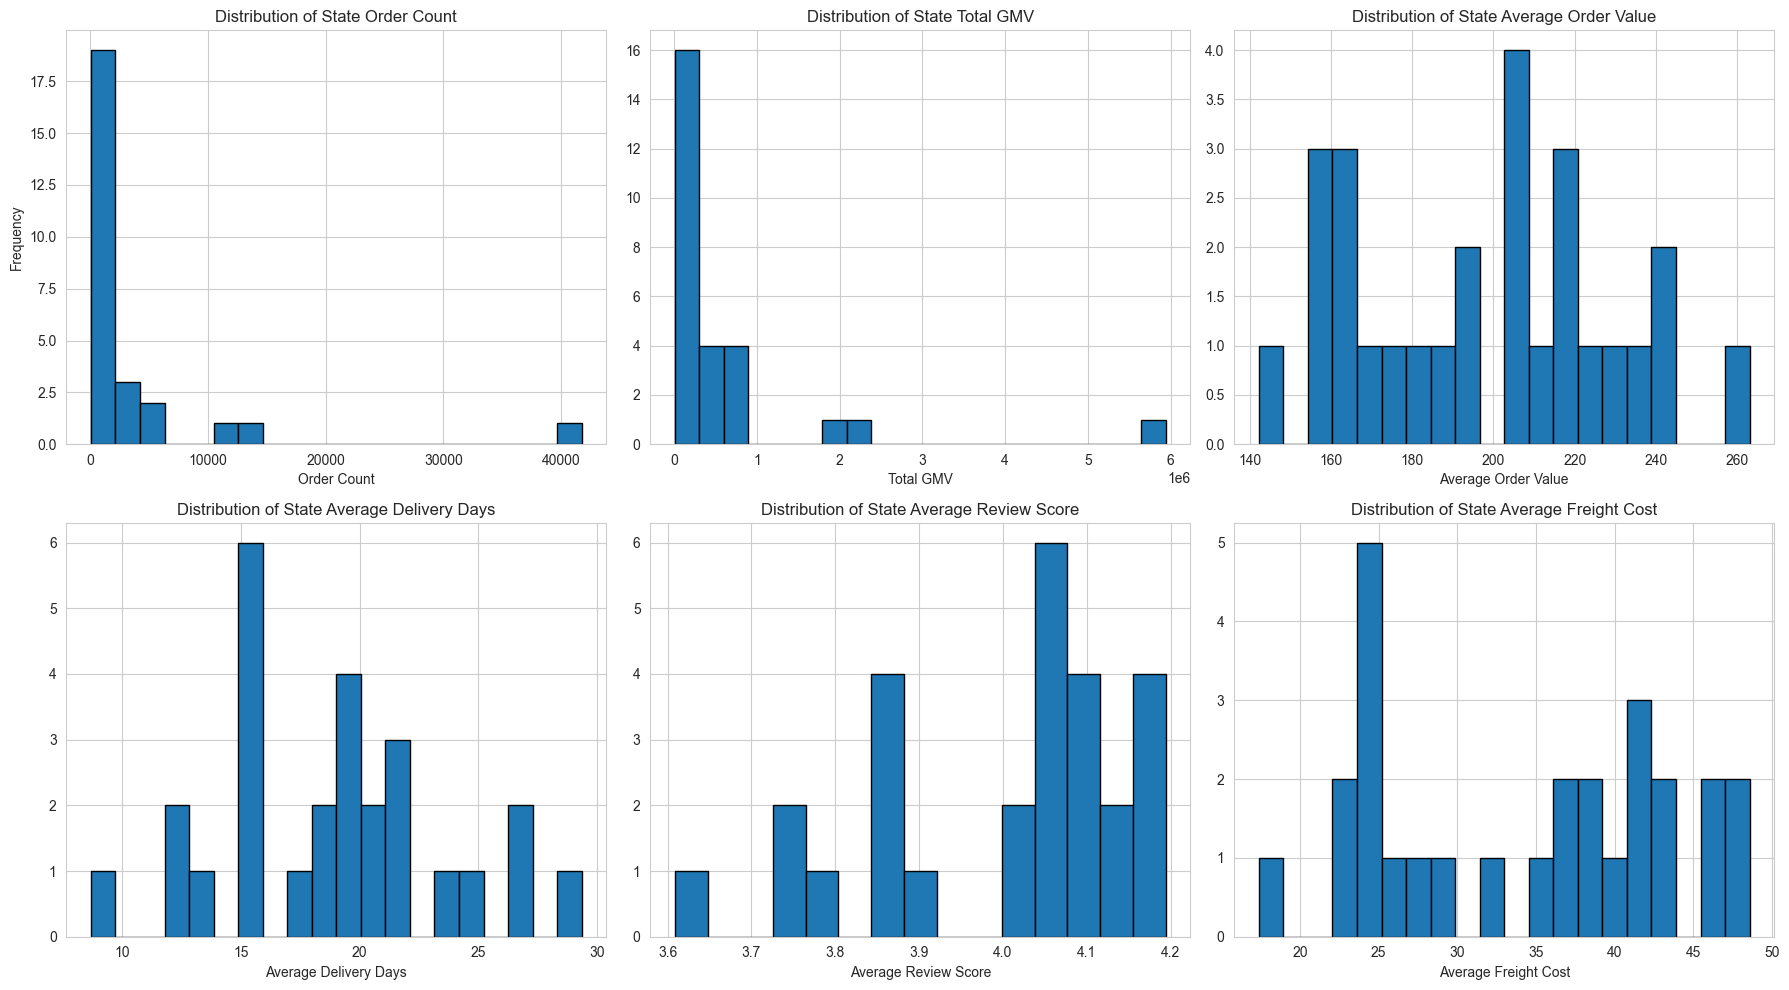

In [14]:
# plot the distribution of major state-level metrics
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# order count
axes[0, 0].hist(df_state["order_count"], bins=20, edgecolor="black")
axes[0, 0].set_title("Distribution of State Order Count")
axes[0, 0].set_xlabel("Order Count")
axes[0, 0].set_ylabel("Frequency")

# total GMV
axes[0, 1].hist(df_state["total_gmv"], bins=20, edgecolor="black")
axes[0, 1].set_title("Distribution of State Total GMV")
axes[0, 1].set_xlabel("Total GMV")

# average order value
axes[0, 2].hist(df_state["avg_order_value"], bins=20, edgecolor="black")
axes[0, 2].set_title("Distribution of State Average Order Value")
axes[0, 2].set_xlabel("Average Order Value")

# average delivery days
axes[1, 0].hist(df_state["avg_delivery_days"], bins=20, edgecolor="black")
axes[1, 0].set_title("Distribution of State Average Delivery Days")
axes[1, 0].set_xlabel("Average Delivery Days")

# average review score
axes[1, 1].hist(df_state["avg_review_score"], bins=15, edgecolor="black")
axes[1, 1].set_title("Distribution of State Average Review Score")
axes[1, 1].set_xlabel("Average Review Score")

# average freight cost
axes[1, 2].hist(df_state["avg_freight_cost"], bins=20, edgecolor="black")
axes[1, 2].set_title("Distribution of State Average Freight Cost")
axes[1, 2].set_xlabel("Average Freight Cost")

plt.tight_layout()
plt.show()

In [15]:
# summary statistics for key state-level variables

summary_stats_state = df_state[
    [
        "order_count",
        "customer_count",
        "total_gmv",
        "total_revenue",
        "avg_order_value",
        "avg_delivery_days",
        "avg_freight_cost",
        "delay_rate",
        "avg_review_score",
        "bad_review_rate",
        "repeat_rate"
    ]
].describe().T

summary_stats_state

,count,mean,std,min,25%,50%,75%,max
order_count,27.0,3683.000000,8.270438e+03,46.000000,381.500000,907.000000,2760.000000,4.174600e+04
customer_count,27.0,3683.000000,8.270438e+03,46.000000,381.500000,907.000000,2760.000000,4.174600e+04
total_gmv,27.0,588328.151852,1.190565e+06,10064.620000,84744.620000,186410.980000,482907.305000,5.939079e+06
total_revenue,27.0,504666.432963,1.043176e+06,7829.430000,69692.815000,156663.430000,407876.495000,5.218071e+06
avg_order_value,27.0,197.531735,3.112273e+01,142.267029,167.095850,202.703373,218.959508,2.630370e+02
avg_delivery_days,27.0,18.719604,4.906947e+00,8.703300,15.398250,19.223200,21.333600,2.934150e+01
avg_freight_cost,27.0,34.376477,9.188372e+00,17.372442,24.889408,36.442957,41.529984,4.859109e+01
delay_rate,27.0,8.831119,4.544027e+00,2.702700,4.991645,9.261500,11.279345,2.058111e+01
avg_review_score,27.0,4.003778,1.557410e-01,3.608700,3.871400,4.056200,4.106350,4.194000e+00
bad_review_rate,27.0,16.357928,3.864478e+00,7.462690,13.946670,15.000000,19.223895,2.391304e+01


### State-level Numerical Distribution Analysis
The state-level distribution results show that regional performance is highly uneven across Brazil. Both `order_count` and `total_gmv` are strongly right-skewed, indicating that a small number of states contribute a disproportionately large share of orders and sales. By contrast, `avg_order_value` is more concentrated, suggesting that cross-state differences in transaction value are smaller than differences in sales scale. Logistics indicators such as `avg_delivery_days` and `avg_freight_cost` still show noticeable variation, while `avg_review_score` remains relatively stable around 4.0. In addition, `repeat_rate` is constant at 1.0 for all states, so it is unlikely to provide useful value in later state-level comparison.

## 2.3 State Coverage Check

Before moving to state comparison, it is useful to confirm how many Brazilian states are covered in the dataset and whether regional sales are broadly distributed across the country. This step helps verify the geographic completeness of the analysis and provides basic context for later state-level ranking and map-based visualisation.

In [16]:
# check number of states and basic state coverage

print("Number of states covered in df_state:")
print(df_state["customer_state"].nunique())

print("\nState list:")
print(sorted(df_state["customer_state"].unique()))

print("\nOrder count by state:")
display(
    df_state[["customer_state", "order_count"]]
    .sort_values("order_count", ascending=False)
)

Number of states covered in df_state:
27

State list:
['AC', 'AL', 'AM', 'AP', 'BA', 'CE', 'DF', 'ES', 'GO', 'MA', 'MG', 'MS', 'MT', 'PA', 'PB', 'PE', 'PI', 'PR', 'RJ', 'RN', 'RO', 'RR', 'RS', 'SC', 'SE', 'SP', 'TO']

Order count by state:


,customer_state,order_count
25,SP,41746
18,RJ,12852
10,MG,11635
22,RS,5466
17,PR,5045
23,SC,3637
4,BA,3380
6,DF,2140
7,ES,2033
8,GO,2020


In [17]:
# optional: add state full names for easier interpretation

brazil_states = {
    "AC": "Acre",
    "AL": "Alagoas",
    "AP": "Amapa",
    "AM": "Amazonas",
    "BA": "Bahia",
    "CE": "Ceara",
    "DF": "Distrito Federal",
    "ES": "Espirito Santo",
    "GO": "Goias",
    "MA": "Maranhao",
    "MT": "Mato Grosso",
    "MS": "Mato Grosso do Sul",
    "MG": "Minas Gerais",
    "PA": "Para",
    "PB": "Paraiba",
    "PR": "Parana",
    "PE": "Pernambuco",
    "PI": "Piaui",
    "RJ": "Rio de Janeiro",
    "RN": "Rio Grande do Norte",
    "RS": "Rio Grande do Sul",
    "RO": "Rondonia",
    "RR": "Roraima",
    "SC": "Santa Catarina",
    "SP": "Sao Paulo",
    "SE": "Sergipe",
    "TO": "Tocantins"
}

df_state["state_name"] = df_state["customer_state"].map(brazil_states)

df_state[["customer_state", "state_name", "order_count"]].sort_values("order_count", ascending=False).head(10)

,customer_state,state_name,order_count
25,SP,Sao Paulo,41746
18,RJ,Rio de Janeiro,12852
10,MG,Minas Gerais,11635
22,RS,Rio Grande do Sul,5466
17,PR,Parana,5045
23,SC,Santa Catarina,3637
4,BA,Bahia,3380
6,DF,Distrito Federal,2140
7,ES,Espirito Santo,2033
8,GO,Goias,2020


### State Coverage Check
The dataset covers all 27 Brazilian states and federal units, which means the geographic analysis has full national coverage. This provides a complete basis for later ranking and regional comparison.

However, order volume is highly concentrated in a few leading states. SP ranks first by a large margin, followed by RJ and MG. After these three, the order count drops clearly, suggesting that most platform activity is concentrated in a limited number of major regional markets.

## 2.4 Preliminary Regional Concentration Check

Before moving to formal regional ranking analysis, it is useful to make a preliminary check of how concentrated regional sales are. This provides an early indication of whether platform revenue is broadly distributed across many states or strongly dependent on a small number of major regional markets.

In [18]:
# calculate state-level GMV share

df_concentration_state = df_state[["customer_state", "total_gmv"]].copy()
df_concentration_state["gmv_share_pct"] = (
    df_concentration_state["total_gmv"] / df_concentration_state["total_gmv"].sum() * 100
)

df_concentration_state = df_concentration_state.sort_values("total_gmv", ascending=False)

print("Top 10 states by GMV share:")
display(df_concentration_state.head(10))

print(f"GMV share of top 3 states: {df_concentration_state.head(3)['gmv_share_pct'].sum():.2f}%")
print(f"GMV share of top 5 states: {df_concentration_state.head(5)['gmv_share_pct'].sum():.2f}%")
print(f"GMV share of top 10 states: {df_concentration_state.head(10)['gmv_share_pct'].sum():.2f}%")

Top 10 states by GMV share:


,customer_state,total_gmv,gmv_share_pct
25,SP,5939079.38,37.388301
18,RJ,2135055.75,13.440822
10,MG,1860210.66,11.710589
22,RS,888633.27,5.594215
17,PR,803460.57,5.058027
4,BA,612431.53,3.855442
23,SC,611253.71,3.848027
6,DF,354560.90,2.232068
8,GO,350209.80,2.204677
7,ES,325288.44,2.047789


GMV share of top 3 states: 62.54%
GMV share of top 5 states: 73.19%
GMV share of top 10 states: 87.38%


### Preliminary Regional Concentration Check Analysis
The concentration results show that regional sales are heavily dominated by a few major states. SP alone contributes about 37.39% of total GMV, while SP, RJ, and MG together account for 62.54%.

This concentration becomes even clearer when looking at broader groups: the top 5 states contribute 73.19% of GMV, and the top 10 states contribute 87.38%. This indicates that the platform relies strongly on a small number of core regional markets.

## 3. Regional Sales Ranking Analysis

Regional sales ranking analysis aims to identify the strongest and weakest state-level markets from multiple business perspectives. Instead of looking at only one metric, this section compares states by GMV, order volume, and average order value. This helps distinguish states that are commercially dominant from those that may still have growth potential.

### 3.1 Top 10 States by GMV

GMV is one of the most direct indicators of regional business value. Analysing the top states by total GMV helps identify which regional markets contribute most strongly to the platform’s sales performance.

In [20]:
# rank states by total GMV

top10_gmv_states = (
    df_state[["customer_state", "total_gmv", "order_count", "customer_count", "avg_review_score"]]
    .sort_values("total_gmv", ascending=False)
    .head(10)
)

print("Top 10 states by total GMV")
display(top10_gmv_states)

Top 10 states by total GMV


,customer_state,total_gmv,order_count,customer_count,avg_review_score
25,SP,5939079.38,41746,41746,4.1756
18,RJ,2135055.75,12852,12852,3.8806
10,MG,1860210.66,11635,11635,4.1389
22,RS,888633.27,5466,5466,4.1363
17,PR,803460.57,5045,5045,4.1847
4,BA,612431.53,3380,3380,3.8622
23,SC,611253.71,3637,3637,4.0764
6,DF,354560.90,2140,2140,4.0693
8,GO,350209.80,2020,2020,4.0435
7,ES,325288.44,2033,2033,4.0394


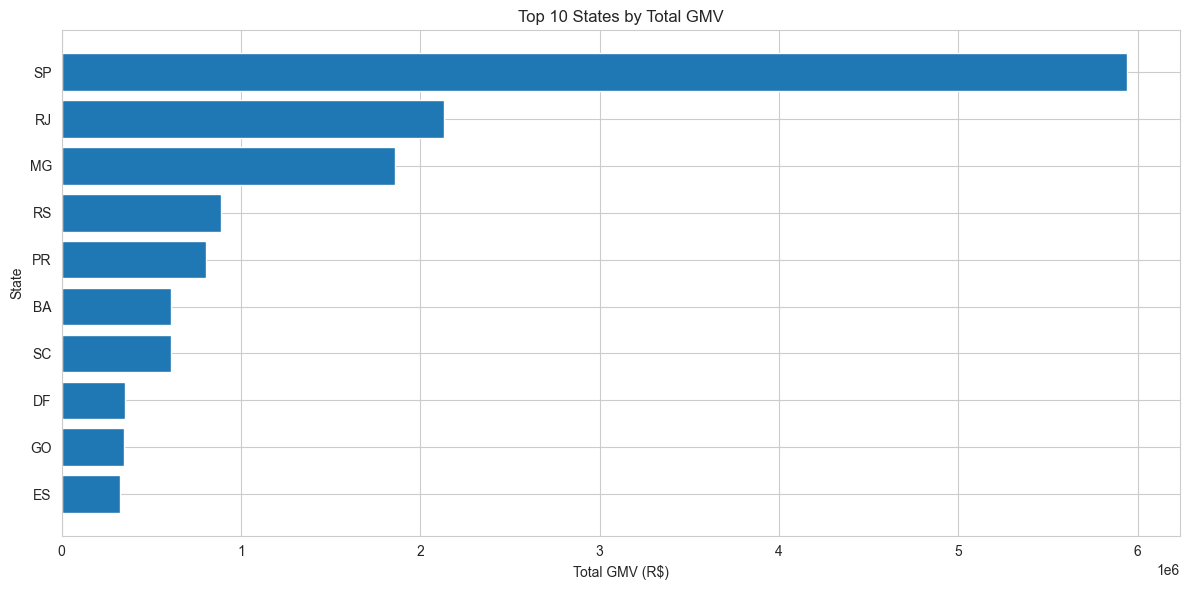

In [21]:
# visualise top 10 states by total GMV

plt.figure(figsize=(12, 6))
plt.barh(top10_gmv_states["customer_state"], top10_gmv_states["total_gmv"])
plt.xlabel("Total GMV (R$)")
plt.ylabel("State")
plt.title("Top 10 States by Total GMV")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Top 10 States by GMV Analysis
`SP` is by far the largest regional market in terms of GMV, contributing much more than any other state. `RJ` and `MG` rank second and third, but both remain far below `SP`, which shows a strong concentration of platform sales in a few leading markets.

Among the top 10 states, most also have relatively solid review scores, but `RJ` and `BA` stand out with lower satisfaction levels than the other major markets. This suggests that some high-value regional markets are commercially strong while still facing customer experience risk.

### 3.2 Top 10 States by Order Count

Order count reflects how frequently a state generates transactions and is an important indicator of market activity. While GMV highlights business value, order volume reveals the breadth of regional demand. Analysing the top states by order count helps compare market size with the GMV ranking above.

In [22]:
# rank states by order count

top10_orders_states = (
    df_state[["customer_state", "order_count", "total_gmv", "avg_review_score"]]
    .sort_values("order_count", ascending=False)
    .head(10)
)

print("Top 10 states by order count")
display(top10_orders_states)

Top 10 states by order count


,customer_state,order_count,total_gmv,avg_review_score
25,SP,41746,5939079.38,4.1756
18,RJ,12852,2135055.75,3.8806
10,MG,11635,1860210.66,4.1389
22,RS,5466,888633.27,4.1363
17,PR,5045,803460.57,4.1847
23,SC,3637,611253.71,4.0764
4,BA,3380,612431.53,3.8622
6,DF,2140,354560.90,4.0693
7,ES,2033,325288.44,4.0394
8,GO,2020,350209.80,4.0435


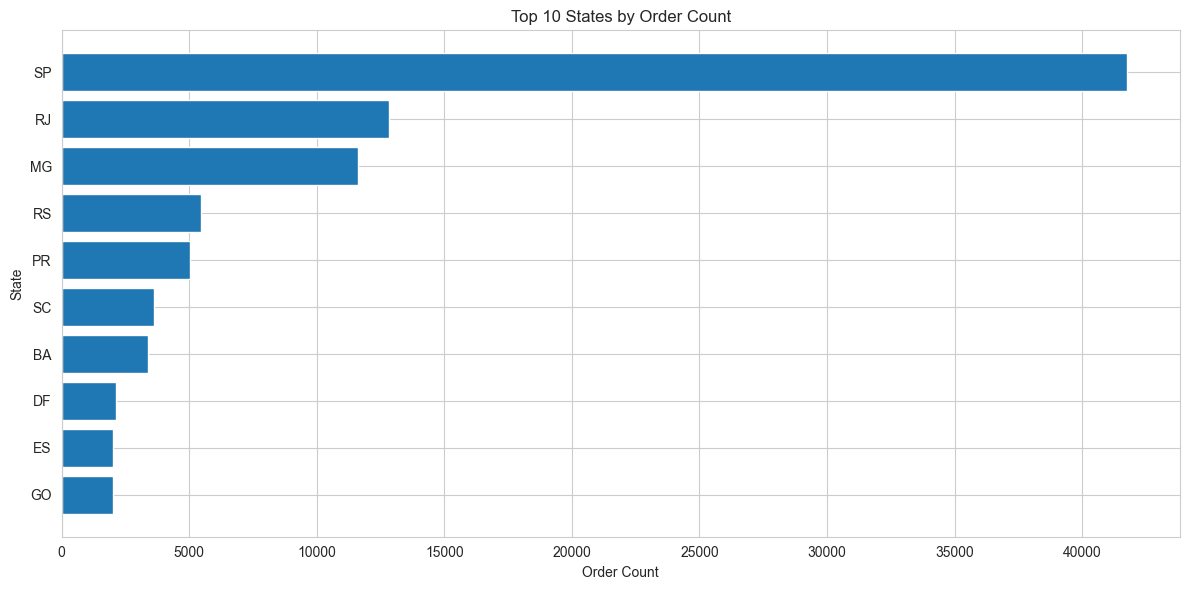

In [23]:
# visualise top 10 states by order count

plt.figure(figsize=(12, 6))
plt.barh(top10_orders_states["customer_state"], top10_orders_states["order_count"])
plt.xlabel("Order Count")
plt.ylabel("State")
plt.title("Top 10 States by Order Count")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
### Top 10 States by Order Count Analysis
